###

### Cell 1 — Config / imports / constants

In [40]:
# Cell 1 — Config / imports / constants

from pathlib import Path
from collections import defaultdict, deque
import zipfile

import requests
import geopandas as gpd
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# -----------------------------
# Paths
# -----------------------------
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Core analysis settings
# -----------------------------
LOW_IGS_THRESHOLD = 45

ANALYSIS_YEARS = list(range(2017, 2025))  # ACS-aligned years only
PRE_COVID_YEARS = [2017, 2018, 2019]
COVID_YEARS = [2020, 2021]
RECOVERY_YEARS = [2022, 2023, 2024]
PERIOD_ORDER = ["pre_covid", "covid", "recovery"]

ECON_VARS = [
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

CLUSTER_CORE_VARS = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

DISPLAY_COLS = [
    "display_state",
    "display_county",
    "display_name",
]

REQUIRED_PANEL_COLS = [
    "geoid",
    "year",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

PANEL_CANDIDATES = [
    OUT_DIR / "eda_panel_clean.parquet",
    OUT_DIR / "igs_x_acs_full.parquet",
]

# -----------------------------
# Cluster-building settings
# -----------------------------
MIN_CLUSTER_TRACTS = 3
MIN_CLUSTER_POP = 5000

COUNTY_SIGNAL_POOL_N = 1500
TARGET_SEED_COUNTIES_N = 40
PER_STATE_BASE_COUNTIES = 1
PER_STATE_MAX_COUNTIES = 3
MIN_SIGNAL_TRACTS_PER_COUNTY = 2
BROADER_MAX_PER_COUNTY = 35
CONNECTOR_HOPS = 1

TRACT_BASE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/TRACT/"
TRACT_ROOT_DIR = RAW_DIR / "tl_2024_state_tracts"
TRACT_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Enrichment settings
# -----------------------------
ENRICHMENT_TOP_K = 15

### Cell 2 — Shared helpers

In [41]:
# Cell 2 — Shared helpers

def normalize_geoid_series(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_mask = numeric.notna()

    s = s.copy()
    s.loc[numeric_mask] = numeric.loc[numeric_mask].astype("Int64").astype("string")
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)

    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)


def add_display_fields(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "display_state" not in out.columns:
        state_a = out["State"] if "State" in out.columns else pd.Series(pd.NA, index=out.index, dtype="string")
        state_b = out["state"] if "state" in out.columns else pd.Series(pd.NA, index=out.index, dtype="string")
        out["display_state"] = state_a.fillna(state_b)

    if "display_county" not in out.columns:
        county_a = out["County"] if "County" in out.columns else pd.Series(pd.NA, index=out.index, dtype="string")
        county_b = out["county"] if "county" in out.columns else pd.Series(pd.NA, index=out.index, dtype="string")
        out["display_county"] = county_a.fillna(county_b)

    if "display_name" not in out.columns:
        if "NAME" in out.columns:
            out["display_name"] = out["NAME"].astype("string")
        elif "Census Tract FIPS code" in out.columns:
            out["display_name"] = "Census Tract " + out["Census Tract FIPS code"].astype("string")
        else:
            out["display_name"] = out["geoid"].astype("string")

    return out


def assign_period(year: int) -> str:
    if year in PRE_COVID_YEARS:
        return "pre_covid"
    if year in COVID_YEARS:
        return "covid"
    if year in RECOVERY_YEARS:
        return "recovery"
    return "outside_scope"


def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")


def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")


def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")

    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())

    return float(np.average(values.loc[mask], weights=weights.loc[mask]))


def require_columns(df: pd.DataFrame, required_cols: list[str], df_name: str = "DataFrame") -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")


def load_analysis_panel() -> tuple[pd.DataFrame, str]:
    df = None
    source = None

    # Controlled notebook fallback, kept for convenience but no longer repeated everywhere
    for var_name in ["eda_df", "model_df_full"]:
        if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
            df = globals()[var_name].copy()
            source = f"existing global: {var_name}"
            break

    if df is None:
        for p in PANEL_CANDIDATES:
            if p.exists():
                df = pd.read_parquet(p)
                source = f"file: {p}"
                break

    if df is None:
        searched = ", ".join(str(p) for p in PANEL_CANDIDATES)
        raise FileNotFoundError(
            "Could not find a processed merged panel. "
            f"Expected one of: {searched}"
        )

    df = df.copy()
    require_columns(df, REQUIRED_PANEL_COLS, "analysis panel source")

    df["geoid"] = normalize_geoid_series(df["geoid"])
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df = df[df["year"].isin(ANALYSIS_YEARS)].copy()
    df["year"] = df["year"].astype(int)

    df = add_display_fields(df)

    df = (
        df.sort_values(["geoid", "year"])
          .drop_duplicates(["geoid", "year"])
          .reset_index(drop=True)
    )

    df["analysis_period"] = df["year"].map(assign_period)
    return df, source


def load_state_tract_geometry(state_fips_list: list[str]) -> gpd.GeoDataFrame:
    tract_gdf_list = []

    for st in state_fips_list:
        zip_name = f"tl_2024_{st}_tract.zip"
        shp_name = f"tl_2024_{st}_tract.shp"
        zip_path = TRACT_ROOT_DIR / zip_name
        extract_dir = TRACT_ROOT_DIR / f"tl_2024_{st}_tract"
        shp_path = extract_dir / shp_name

        if not shp_path.exists():
            extract_dir.mkdir(parents=True, exist_ok=True)

            if not zip_path.exists():
                url = f"{TRACT_BASE_URL}{zip_name}"
                print(f"Downloading {url}")
                r = requests.get(url, timeout=120)
                r.raise_for_status()
                with open(zip_path, "wb") as f:
                    f.write(r.content)

            print(f"Extracting {zip_name}")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

        if not shp_path.exists():
            raise FileNotFoundError(f"Missing shapefile after extraction: {shp_path}")

        gdf_state = gpd.read_file(shp_path)
        tract_gdf_list.append(gdf_state)

    if not tract_gdf_list:
        raise ValueError("No tract geometries were loaded.")

    tract_gdf = pd.concat(tract_gdf_list, ignore_index=True)
    tract_gdf = gpd.GeoDataFrame(
        tract_gdf,
        geometry="geometry",
        crs=tract_gdf_list[0].crs,
    )

    tract_gdf["geoid"] = normalize_geoid_series(tract_gdf["GEOID"])
    tract_gdf = tract_gdf.dropna(subset=["geoid", "geometry"]).copy()
    tract_gdf = tract_gdf[tract_gdf.geometry.notna()].copy()
    tract_gdf = tract_gdf[~tract_gdf.geometry.is_empty].copy()
    tract_gdf = tract_gdf.drop_duplicates(subset=["geoid"]).copy()

    return tract_gdf


def build_adjacency_edges_fast(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    edge_frames = []

    for (state_name, county_name), grp in gdf.groupby(["display_state", "display_county"], dropna=False):
        grp = grp[["geoid", "display_state", "display_county", "geometry"]].dropna(subset=["geoid", "geometry"]).copy()

        if len(grp) < 2:
            continue

        left = grp[["geoid", "geometry"]].copy()
        right = grp[["geoid", "geometry"]].copy()

        joined = gpd.sjoin(left, right, how="inner", predicate="touches")
        if joined.empty:
            continue

        joined = joined.reset_index(drop=True)
        joined = joined.rename(columns={"geoid_left": "geoid_1", "geoid_right": "geoid_2"})
        joined = joined[joined["geoid_1"] != joined["geoid_2"]].copy()

        if joined.empty:
            continue

        joined["a"] = joined[["geoid_1", "geoid_2"]].min(axis=1)
        joined["b"] = joined[["geoid_1", "geoid_2"]].max(axis=1)
        joined = joined.drop_duplicates(subset=["a", "b"]).copy()

        out = joined[["a", "b"]].rename(columns={"a": "geoid_1", "b": "geoid_2"})
        out["display_state"] = state_name
        out["display_county"] = county_name
        edge_frames.append(out)

    if not edge_frames:
        return pd.DataFrame(columns=["display_state", "display_county", "geoid_1", "geoid_2"])

    return pd.concat(edge_frames, ignore_index=True)


def connected_components_from_edges(nodes: list[str], edges_df: pd.DataFrame) -> dict[str, int]:
    neighbors = defaultdict(set)
    for n in nodes:
        neighbors[n] = set()

    if edges_df is not None and len(edges_df) > 0:
        for _, row in edges_df.iterrows():
            a = str(row["geoid_1"])
            b = str(row["geoid_2"])
            neighbors[a].add(b)
            neighbors[b].add(a)

    visited = set()
    node_to_cluster_num = {}
    cluster_num = 0

    for n in nodes:
        if n in visited:
            continue

        cluster_num += 1
        q = deque([n])
        visited.add(n)

        while q:
            cur = q.popleft()
            node_to_cluster_num[cur] = cluster_num
            for nxt in neighbors[cur]:
                if nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)

    return node_to_cluster_num


def diversified_seed_counties(
    county_signal_df: pd.DataFrame,
    target_n: int,
    per_state_base: int,
    per_state_max: int,
) -> pd.DataFrame:
    county_signal_df = county_signal_df.copy()
    county_signal_df = county_signal_df.sort_values(
        ["display_state", "county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[True, False, False, False, True],
    ).reset_index(drop=True)

    county_signal_df["state_rank"] = county_signal_df.groupby("display_state").cumcount() + 1

    base = county_signal_df.loc[county_signal_df["state_rank"] <= per_state_base]
    selected = base[["display_state", "display_county"]].drop_duplicates()

    selected_state_counts = selected.groupby("display_state").size().to_dict() if len(selected) > 0 else {}

    remaining = county_signal_df.merge(
        selected,
        on=["display_state", "display_county"],
        how="left",
        indicator=True,
    )
    remaining = remaining.loc[remaining["_merge"] == "left_only"].drop(columns="_merge")
    remaining = remaining.sort_values(
        ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    chosen_rows = [selected.copy()] if len(selected) > 0 else []

    for _, row in remaining.iterrows():
        state_name = row["display_state"]
        current_ct = selected_state_counts.get(state_name, 0)
        if current_ct >= per_state_max:
            continue

        candidate = pd.DataFrame([{
            "display_state": row["display_state"],
            "display_county": row["display_county"],
        }])
        chosen_rows.append(candidate)
        selected_state_counts[state_name] = current_ct + 1

        if sum(selected_state_counts.values()) >= target_n:
            break

    if len(chosen_rows) == 0:
        return pd.DataFrame(columns=["display_state", "display_county"])

    out = (
        pd.concat(chosen_rows, ignore_index=True)
          .drop_duplicates(subset=["display_state", "display_county"])
          .reset_index(drop=True)
    )
    return out

### Cell 3 — Load the tract-year panel

In [42]:
# Cell 3 — Load the tract-year panel

panel_df, PANEL_SOURCE = load_analysis_panel()

analysis_cols = ["geoid", "year", "analysis_period"] + DISPLAY_COLS + CLUSTER_CORE_VARS
analysis_panel = panel_df[analysis_cols].copy()

print("Loaded panel from:", PANEL_SOURCE)
print("Analysis panel shape:", analysis_panel.shape)
print("Unique tracts:", analysis_panel["geoid"].nunique())
print("Years:", sorted(analysis_panel["year"].unique().tolist()))
print("Periods:", analysis_panel["analysis_period"].value_counts(dropna=False).to_dict())
print()
print("Missingness in core vars:")
print(analysis_panel[CLUSTER_CORE_VARS].isna().mean().sort_values(ascending=False))
print()
print(analysis_panel.head())

if analysis_panel.empty:
    raise ValueError("analysis_panel is empty after loading and year filtering.")

Loaded panel from: file: data\processed\eda_panel_clean.parquet
Analysis panel shape: (680256, 13)
Unique tracts: 85032
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Periods: {'pre_covid': 255096, 'recovery': 255096, 'covid': 170064}

Missingness in core vars:
median_household_income    0.116411
poverty_rate               0.111802
unemp_rate                 0.111357
lfpr_16p                   0.109857
pop_total                  0.104783
igs_total                  0.008863
igs_economy                0.001313
dtype: float64

         geoid  year analysis_period display_state  display_county                               display_name  igs_total  igs_economy  poverty_rate  unemp_rate  median_household_income  lfpr_16p  \
0  01001020100  2017       pre_covid       Alabama  Autauga County  Census Tract 201, Autauga County, Alabama       47.0         34.0      0.106775    0.045504                  67826.0  0.622387   
1  01001020100  2018       pre_covid       Alabama  Autauga Count

### Cell 4 — Build the tract-to-cluster map

In [43]:
# Cell 4 — Build the tract-to-cluster map

# --------------------------------------------------
# A. Build recovery-period tract scoring base
# --------------------------------------------------
tract_recovery = (
    analysis_panel.loc[analysis_panel["analysis_period"] == "recovery"]
    .groupby(["geoid", "display_state", "display_county", "display_name"], as_index=False)
    .agg({
        "igs_total": "mean",
        "igs_economy": "mean",
        "poverty_rate": "mean",
        "unemp_rate": "mean",
        "median_household_income": "mean",
        "lfpr_16p": "mean",
        "pop_total": "mean",
    })
    .copy()
)

tract_recovery["score_low_igs"] = (
    bad_when_low(tract_recovery["igs_total"]) +
    bad_when_low(tract_recovery["igs_economy"])
) / 2

tract_recovery["score_econ_vulnerability"] = (
    bad_when_low(tract_recovery["igs_economy"]) +
    bad_when_high(tract_recovery["poverty_rate"]) +
    bad_when_high(tract_recovery["unemp_rate"]) +
    bad_when_low(tract_recovery["median_household_income"]) +
    bad_when_low(tract_recovery["lfpr_16p"])
) / 5

tract_recovery["scope_score"] = 100 * (
    0.50 * tract_recovery["score_low_igs"] +
    0.50 * tract_recovery["score_econ_vulnerability"]
)

tract_recovery = tract_recovery.sort_values(
    ["scope_score", "igs_total"],
    ascending=[False, True],
).reset_index(drop=True)

# --------------------------------------------------
# B. Use the larger signal pool to identify strong counties
# --------------------------------------------------
signal_pool = tract_recovery.head(COUNTY_SIGNAL_POOL_N).copy()

county_signal = (
    signal_pool
    .groupby(["display_state", "display_county"], as_index=False)
    .agg(
        n_signal_tracts=("geoid", "nunique"),
        mean_scope_score=("scope_score", "mean"),
        median_scope_score=("scope_score", "median"),
        mean_igs_total=("igs_total", "mean"),
        min_igs_total=("igs_total", "min"),
        total_signal_pop=("pop_total", "sum"),
    )
    .copy()
)

county_signal = county_signal.loc[
    county_signal["n_signal_tracts"] >= MIN_SIGNAL_TRACTS_PER_COUNTY
].copy()

county_signal["county_seed_score"] = (
    0.40 * bad_when_high(county_signal["n_signal_tracts"]) +
    0.35 * bad_when_high(county_signal["mean_scope_score"]) +
    0.15 * bad_when_low(county_signal["mean_igs_total"]) +
    0.10 * bad_when_low(county_signal["min_igs_total"])
)

county_signal = county_signal.sort_values(
    ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

seed_counties = diversified_seed_counties(
    county_signal_df=county_signal,
    target_n=TARGET_SEED_COUNTIES_N,
    per_state_base=PER_STATE_BASE_COUNTIES,
    per_state_max=PER_STATE_MAX_COUNTIES,
)

seed_counties = (
    seed_counties
    .merge(
        county_signal[
            ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
        ],
        on=["display_state", "display_county"],
        how="left",
        validate="1:1",
    )
    .sort_values(["county_seed_score", "n_signal_tracts", "mean_scope_score"], ascending=[False, False, False])
    .reset_index(drop=True)
)

# --------------------------------------------------
# C. Expand within selected counties
# --------------------------------------------------
broader_county_pool = (
    tract_recovery
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner",
    )
    .copy()
)

broader_county_pool["county_rank_by_score"] = (
    broader_county_pool.groupby(["display_state", "display_county"])["scope_score"]
    .rank(method="first", ascending=False)
)

core_scope_df = (
    broader_county_pool.loc[broader_county_pool["county_rank_by_score"] <= BROADER_MAX_PER_COUNTRY]
    if False else broader_county_pool.loc[broader_county_pool["county_rank_by_score"] <= BROADER_MAX_PER_COUNTY]
).drop(columns=["county_rank_by_score"]).drop_duplicates(subset=["geoid"]).sort_values(
    ["display_state", "display_county", "scope_score"],
    ascending=[True, True, False],
).reset_index(drop=True)

# --------------------------------------------------
# D. Load geometry only for selected states
# --------------------------------------------------
needed_state_fips = sorted(core_scope_df["geoid"].astype(str).str[:2].dropna().unique().tolist())
tract_gdf = load_state_tract_geometry(needed_state_fips)

tract_geo_scored = tract_gdf.merge(
    tract_recovery,
    on="geoid",
    how="inner",
    validate="1:1",
)

seed_county_gdf = (
    tract_geo_scored
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner",
    )
    .copy()
)

seed_county_gdf = seed_county_gdf[seed_county_gdf.geometry.notna()].copy()
seed_county_gdf = seed_county_gdf[~seed_county_gdf.geometry.is_empty].copy()

# --------------------------------------------------
# E. Add one-hop geographic connector tracts
# --------------------------------------------------
full_seed_edges = build_adjacency_edges_fast(seed_county_gdf)

core_nodes = set(core_scope_df["geoid"].astype(str).tolist())
expanded_nodes = set(core_nodes)

for _ in range(CONNECTOR_HOPS):
    if full_seed_edges.empty:
        break

    touching_core = full_seed_edges[
        full_seed_edges["geoid_1"].astype(str).isin(expanded_nodes) |
        full_seed_edges["geoid_2"].astype(str).isin(expanded_nodes)
    ].copy()

    neighbor_nodes = (
        set(touching_core["geoid_1"].astype(str).tolist()) |
        set(touching_core["geoid_2"].astype(str).tolist())
    )
    expanded_nodes = expanded_nodes | neighbor_nodes

CLUSTER_SCOPE_DF = (
    seed_county_gdf.loc[seed_county_gdf["geoid"].astype(str).isin(expanded_nodes)]
    .drop_duplicates(subset=["geoid"])
    .sort_values(["display_state", "display_county", "scope_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

adjacency_gdf = CLUSTER_SCOPE_DF.copy()

adjacency_edges = full_seed_edges.loc[
    full_seed_edges["geoid_1"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str))) &
    full_seed_edges["geoid_2"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str)))
].copy()

# --------------------------------------------------
# F. Connected components on broadened scope
# --------------------------------------------------
all_candidate_nodes = adjacency_gdf["geoid"].astype(str).unique().tolist()
node_to_cluster_num = connected_components_from_edges(all_candidate_nodes, adjacency_edges)

adjacency_gdf["cluster_id_num"] = adjacency_gdf["geoid"].astype(str).map(node_to_cluster_num)
adjacency_gdf["cluster_id"] = (
    adjacency_gdf["display_state"].astype(str) +
    " | " +
    adjacency_gdf["display_county"].astype(str) +
    " | cluster_" +
    adjacency_gdf["cluster_id_num"].astype(str)
)

tract_cluster_map = (
    adjacency_gdf[["geoid", "cluster_id", "display_state", "display_county", "display_name"]]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

tract_cluster_map["n_cluster_tracts"] = tract_cluster_map.groupby("cluster_id")["geoid"].transform("nunique")

# --------------------------------------------------
# G. Save outputs
# --------------------------------------------------
tract_cluster_map.to_parquet(OUT_DIR / "tract_cluster_map.parquet", index=False)
CLUSTER_SCOPE_DF.drop(columns="geometry").to_parquet(OUT_DIR / "cluster_scope_df.parquet", index=False)
adjacency_gdf.drop(columns="geometry").to_parquet(OUT_DIR / "adjacency_cluster_gdf.parquet", index=False)
seed_counties.to_parquet(OUT_DIR / "seed_counties.parquet", index=False)
county_signal.to_parquet(OUT_DIR / "county_signal.parquet", index=False)

# --------------------------------------------------
# H. Diagnostics
# --------------------------------------------------
print("Recovery tract universe:", tract_recovery.shape)
print("Signal pool shape:", signal_pool.shape)
print("County signal shape:", county_signal.shape)
print("Seed counties selected:", seed_counties.shape[0])
print("Needed state FIPS:", needed_state_fips)
print()
print("Seed counties by state:")
print(seed_counties["display_state"].value_counts(dropna=False).sort_values(ascending=False))
print()
print("County-expanded core scope:", core_scope_df.shape)
print("Seed-county tract universe:", seed_county_gdf.shape)
print("Connector hops:", CONNECTOR_HOPS)
print("Final CLUSTER_SCOPE_DF shape:", CLUSTER_SCOPE_DF.shape)
print("Connector tracts added:", len(set(CLUSTER_SCOPE_DF["geoid"]) - set(core_scope_df["geoid"])))
print()
print("Adjacency merge shape:", adjacency_gdf.shape)
print("Adjacency edges shape:", adjacency_edges.shape)
print()
print("tract_cluster_map shape:", tract_cluster_map.shape)
print("Unique tracts mapped:", tract_cluster_map["geoid"].nunique())
print("Unique clusters:", tract_cluster_map["cluster_id"].nunique())
print("Unique states in cluster universe:", tract_cluster_map["display_state"].nunique())
print("Unique counties in cluster universe:", tract_cluster_map["display_county"].nunique())
print()
print("Top 25 seed counties:")
print(
    seed_counties[
        ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
    ].head(25)
)
print()
print("Top 25 clusters by size:")
print(
    tract_cluster_map.groupby(["cluster_id", "display_state", "display_county"], as_index=False)
    .agg(n_cluster_tracts=("geoid", "nunique"))
    .sort_values(["n_cluster_tracts", "cluster_id"], ascending=[False, True])
    .head(25)
)

if tract_cluster_map.empty:
    raise ValueError("tract_cluster_map is empty. Cluster-building failed.")

Recovery tract universe: (84153, 14)
Signal pool shape: (1500, 14)
County signal shape: (190, 9)
Seed counties selected: 40
Needed state FIPS: ['01', '04', '05', '06', '11', '12', '13', '17', '18', '20', '21', '22', '24', '25', '26', '28', '29', '32', '34', '35', '36', '37', '39', '40', '42', '45', '47', '48', '51', '54', '55', '72']

Seed counties by state:
display_state
Puerto Rico             3
Arizona                 3
New Mexico              2
Ohio                    2
Michigan                2
New York                2
Georgia                 1
Indiana                 1
Pennsylvania            1
Illinois                1
Tennessee               1
Wisconsin               1
California              1
Maryland                1
Louisiana               1
Alabama                 1
Missouri                1
Kentucky                1
West Virginia           1
Mississippi             1
New Jersey              1
District of Columbia    1
South Carolina          1
Florida                 1
N

### Cell 5 — Build cluster-year and cluster-period panels

In [44]:
# Cell 5 — Build cluster-year and cluster-period panels

# -----------------------------
# A. Join tract panel to clusters
# -----------------------------
clustered_panel = (
    analysis_panel
    .merge(
        tract_cluster_map[["geoid", "cluster_id", "display_state", "display_county", "n_cluster_tracts"]],
        on="geoid",
        how="inner",
        validate="many_to_one",
        suffixes=("", "_cluster"),
    )
    .copy()
)

clustered_panel["cluster_display_state"] = clustered_panel["display_state_cluster"]
clustered_panel["cluster_display_county"] = clustered_panel["display_county_cluster"]

cluster_metric_cols = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

# -----------------------------
# B. Cluster-year panel
# -----------------------------
cluster_year_rows = []

for (cluster_id, year, period), grp in clustered_panel.groupby(["cluster_id", "year", "analysis_period"], dropna=False):
    igs_vals = pd.to_numeric(grp["igs_total"], errors="coerce")
    valid_igs = igs_vals.notna()
    weights = pd.to_numeric(grp["pop_total"], errors="coerce")

    row = {
        "cluster_id": cluster_id,
        "year": int(year),
        "analysis_period": period,
        "display_state": grp["cluster_display_state"].dropna().iloc[0] if grp["cluster_display_state"].notna().any() else pd.NA,
        "display_county": grp["cluster_display_county"].dropna().iloc[0] if grp["cluster_display_county"].notna().any() else pd.NA,
        "n_cluster_tracts": grp["n_cluster_tracts"].dropna().iloc[0] if grp["n_cluster_tracts"].notna().any() else pd.NA,
        "n_observed_tracts_year": grp["geoid"].nunique(),
        "cluster_pop_total": pd.to_numeric(grp["pop_total"], errors="coerce").sum(min_count=1),
        "low_igs_tract_share": igs_vals.loc[valid_igs].lt(LOW_IGS_THRESHOLD).mean() if valid_igs.any() else np.nan,
    }

    for col in cluster_metric_cols:
        row[col] = safe_weighted_mean(grp[col], weights)

    cluster_year_rows.append(row)

cluster_year_panel = (
    pd.DataFrame(cluster_year_rows)
    .sort_values(["cluster_id", "year"])
    .reset_index(drop=True)
)

print("clustered_panel shape:", clustered_panel.shape)
print("cluster_year_panel shape:", cluster_year_panel.shape)
print("Unique clusters in panel:", cluster_year_panel["cluster_id"].nunique())
print("Years in cluster panel:", sorted(cluster_year_panel["year"].unique().tolist()))
print()
print(cluster_year_panel.head(15))

# -----------------------------
# C. Period-level summaries
# -----------------------------
period_metric_cols = [
    "cluster_pop_total",
    "low_igs_tract_share",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

agg_dict = {
    "display_state": "first",
    "display_county": "first",
    "n_cluster_tracts": "max",
    "cluster_pop_total": "mean",
    "low_igs_tract_share": "mean",
    "igs_total": "mean",
    "igs_economy": "mean",
    "poverty_rate": "mean",
    "unemp_rate": "mean",
    "median_household_income": "mean",
    "lfpr_16p": "mean",
}

if "n_observed_tracts_year" in cluster_year_panel.columns:
    agg_dict["n_observed_tracts_year"] = "min"

cluster_period_panel = (
    cluster_year_panel
    .groupby(["cluster_id", "analysis_period"], as_index=False)
    .agg(agg_dict)
    .copy()
)

cluster_period_panel["analysis_period"] = pd.Categorical(
    cluster_period_panel["analysis_period"],
    categories=PERIOD_ORDER,
    ordered=True,
)

cluster_period_panel = cluster_period_panel.sort_values(
    ["cluster_id", "analysis_period"]
).reset_index(drop=True)

latest_cluster_meta = (
    cluster_year_panel
    .sort_values(["cluster_id", "year"])
    .groupby("cluster_id", as_index=False)
    .tail(1)[["cluster_id", "display_state", "display_county", "n_cluster_tracts", "cluster_pop_total"]]
    .rename(columns={"cluster_pop_total": "latest_cluster_pop_total"})
    .copy()
)

cluster_period_wide = (
    cluster_period_panel
    .pivot(index="cluster_id", columns="analysis_period", values=period_metric_cols)
)

expected_cols = pd.MultiIndex.from_product(
    [period_metric_cols, PERIOD_ORDER],
    names=["metric", "analysis_period"],
)

cluster_period_wide = cluster_period_wide.reindex(columns=expected_cols)
cluster_period_wide.columns = [f"{metric}_{period}" for metric, period in cluster_period_wide.columns]
cluster_period_wide = cluster_period_wide.reset_index()

cluster_period_summary = (
    latest_cluster_meta
    .merge(cluster_period_wide, on="cluster_id", how="left", validate="1:1")
    .copy()
)

# -----------------------------
# D. Completeness and trajectory features
# -----------------------------
cluster_period_summary["has_pre_covid"] = cluster_period_summary["igs_total_pre_covid"].notna()
cluster_period_summary["has_covid"] = cluster_period_summary["igs_total_covid"].notna()
cluster_period_summary["has_recovery"] = cluster_period_summary["igs_total_recovery"].notna()

cluster_period_summary["complete_periods_flag"] = (
    cluster_period_summary["has_pre_covid"] &
    cluster_period_summary["has_covid"] &
    cluster_period_summary["has_recovery"]
)

# Lower is worse
cluster_period_summary["igs_total_drop_pre_to_covid"] = (
    cluster_period_summary["igs_total_pre_covid"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_drop_pre_to_covid"] = (
    cluster_period_summary["igs_economy_pre_covid"] - cluster_period_summary["igs_economy_covid"]
)
cluster_period_summary["igs_total_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_total_recovery"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_economy_recovery"] - cluster_period_summary["igs_economy_covid"]
)

# Higher is worse
cluster_period_summary["poverty_increase_pre_to_covid"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_pre_covid"]
)
cluster_period_summary["unemp_increase_pre_to_covid"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_pre_covid"]
)
cluster_period_summary["poverty_improve_covid_to_recovery"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_recovery"]
)
cluster_period_summary["unemp_improve_covid_to_recovery"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_recovery"]
)

# Higher is better
cluster_period_summary["income_drop_pre_to_covid"] = (
    cluster_period_summary["median_household_income_pre_covid"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_drop_pre_to_covid"] = (
    cluster_period_summary["lfpr_16p_pre_covid"] - cluster_period_summary["lfpr_16p_covid"]
)
cluster_period_summary["income_rebound_covid_to_recovery"] = (
    cluster_period_summary["median_household_income_recovery"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_rebound_covid_to_recovery"] = (
    cluster_period_summary["lfpr_16p_recovery"] - cluster_period_summary["lfpr_16p_covid"]
)

# Structural filters
cluster_period_summary["serious_cluster_flag"] = (
    cluster_period_summary["complete_periods_flag"] &
    (cluster_period_summary["n_cluster_tracts"] >= MIN_CLUSTER_TRACTS) &
    (cluster_period_summary["latest_cluster_pop_total"] >= MIN_CLUSTER_POP)
)

cluster_period_summary["low_igs_recovery_flag"] = (
    cluster_period_summary["igs_total_recovery"] < LOW_IGS_THRESHOLD
)

cluster_period_summary["low_igs_economy_recovery_flag"] = (
    cluster_period_summary["igs_economy_recovery"] < LOW_IGS_THRESHOLD
)

print("cluster_period_panel shape:", cluster_period_panel.shape)
print("cluster_period_summary shape:", cluster_period_summary.shape)
print()
print("Complete-period cluster count:", int(cluster_period_summary["complete_periods_flag"].sum()))
print("Serious cluster count:", int(cluster_period_summary["serious_cluster_flag"].sum()))
print("Recovery low-IGS cluster count:", int(cluster_period_summary["low_igs_recovery_flag"].sum()))
print()
print(
    cluster_period_summary[
        [
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_pre_covid",
            "igs_total_covid",
            "igs_total_recovery",
            "poverty_rate_pre_covid",
            "poverty_rate_covid",
            "poverty_rate_recovery",
            "complete_periods_flag",
            "serious_cluster_flag",
            "low_igs_recovery_flag",
        ]
    ].head(15)
)

if cluster_period_summary.empty:
    raise ValueError("cluster_period_summary is empty.")

clustered_panel shape: (23536, 19)
cluster_year_panel shape: (688, 15)
Unique clusters in panel: 86
Years in cluster panel: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

                             cluster_id  year analysis_period display_state display_county  n_cluster_tracts  n_observed_tracts_year  cluster_pop_total  low_igs_tract_share  igs_total  igs_economy  \
0   Alabama | Mobile County | cluster_1  2017       pre_covid       Alabama  Mobile County                81                      81           174074.0             0.777778  38.670840    40.815976   
1   Alabama | Mobile County | cluster_1  2018       pre_covid       Alabama  Mobile County                81                      81           171909.0             0.753086  37.426682    39.276507   
2   Alabama | Mobile County | cluster_1  2019       pre_covid       Alabama  Mobile County                81                      81           171726.0             0.814815  38.016493    40.396335   
3   Alabama | Mobile Count

### Cell 6 — Score the shortlist and package enrichment-ready outputs

In [45]:
# Cell 6 — Score the shortlist and package enrichment-ready outputs

cluster_scored = cluster_period_summary.copy()

# -----------------------------------
# Score only structurally usable clusters
# -----------------------------------
cluster_scored["eligible_for_scoring"] = (
    cluster_scored["complete_periods_flag"].fillna(False) &
    cluster_scored["serious_cluster_flag"].fillna(False)
)

score_df = cluster_scored.loc[cluster_scored["eligible_for_scoring"]].copy()

# -----------------------------------
# Shock variables
# NOTE:
# Keeping the exact implemented notebook logic here to preserve outputs.
# The original comment says "clip negatives to 0", but the PDF code does not clip.
# -----------------------------------
shock_cols = [
    "igs_total_drop_pre_to_covid",
    "igs_economy_drop_pre_to_covid",
    "poverty_increase_pre_to_covid",
    "unemp_increase_pre_to_covid",
    "income_drop_pre_to_covid",
    "lfpr_drop_pre_to_covid",
]

for col in shock_cols:
    score_df[f"{col}_shock_only"] = pd.to_numeric(score_df[col], errors="coerce")

# -----------------------------------
# Weak recovery shortfall variables
# Higher = weaker recovery
# -----------------------------------
score_df["weakrec_igs_total"] = -pd.to_numeric(score_df["igs_total_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_igs_economy"] = -pd.to_numeric(score_df["igs_economy_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_poverty"] = -pd.to_numeric(score_df["poverty_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_unemp"] = -pd.to_numeric(score_df["unemp_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_income"] = -pd.to_numeric(score_df["income_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_lfpr"] = -pd.to_numeric(score_df["lfpr_rebound_covid_to_recovery"], errors="coerce")

# -----------------------------------
# 1) Low IGS in recovery
# -----------------------------------
score_df["score_low_igs_recovery"] = (
    bad_when_low(score_df["igs_total_recovery"]) +
    bad_when_high(score_df["low_igs_tract_share_recovery"])
) / 2

# -----------------------------------
# 2) Economic vulnerability in recovery
# -----------------------------------
score_df["score_econ_vulnerability_recovery"] = (
    bad_when_low(score_df["igs_economy_recovery"]) +
    bad_when_high(score_df["poverty_rate_recovery"]) +
    bad_when_high(score_df["unemp_rate_recovery"]) +
    bad_when_low(score_df["median_household_income_recovery"]) +
    bad_when_low(score_df["lfpr_16p_recovery"])
) / 5

# -----------------------------------
# 3) COVID shock
# -----------------------------------
score_df["score_covid_shock"] = (
    bad_when_high(score_df["igs_total_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["igs_economy_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["poverty_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["unemp_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["income_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["lfpr_drop_pre_to_covid_shock_only"])
) / 6

# -----------------------------------
# 4) Weak recovery
# -----------------------------------
score_df["score_weak_recovery"] = (
    bad_when_high(score_df["weakrec_igs_total"]) +
    bad_when_high(score_df["weakrec_igs_economy"]) +
    bad_when_high(score_df["weakrec_poverty"]) +
    bad_when_high(score_df["weakrec_unemp"]) +
    bad_when_high(score_df["weakrec_income"]) +
    bad_when_high(score_df["weakrec_lfpr"])
) / 6

# -----------------------------------
# Transparent final shortlist score
# -----------------------------------
score_df["cluster_shortlist_score"] = (
    0.35 * score_df["score_low_igs_recovery"] +
    0.35 * score_df["score_econ_vulnerability_recovery"] +
    0.15 * score_df["score_covid_shock"] +
    0.15 * score_df["score_weak_recovery"]
)

score_cols = [
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]

cluster_scored = cluster_scored.merge(
    score_df[["cluster_id"] + score_cols],
    on="cluster_id",
    how="left",
    validate="1:1",
)

# -----------------------------------
# Final shortlist
# -----------------------------------
cluster_shortlist = (
    cluster_scored.loc[
        cluster_scored["eligible_for_scoring"] &
        cluster_scored["low_igs_recovery_flag"]
    ]
    .sort_values(
        [
            "cluster_shortlist_score",
            "igs_total_recovery",
            "igs_economy_recovery",
            "latest_cluster_pop_total",
        ],
        ascending=[False, True, True, False],
    )
    .reset_index(drop=True)
)

cluster_shortlist["rank"] = np.arange(1, len(cluster_shortlist) + 1)

shortlist_view_cols = [
    "rank",
    "cluster_id",
    "display_state",
    "display_county",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "igs_total_pre_covid",
    "igs_total_covid",
    "igs_total_recovery",
    "low_igs_tract_share_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]

print("Scoring universe shape:", score_df.shape)
print("Final shortlist shape:", cluster_shortlist.shape)
print()
print(cluster_shortlist[shortlist_view_cols].head(20))

# -----------------------------------
# Save core shortlist outputs
# -----------------------------------
cluster_year_panel.to_parquet(OUT_DIR / "cluster_year_panel.parquet", index=False)
cluster_period_summary.to_parquet(OUT_DIR / "cluster_period_summary.parquet", index=False)
cluster_shortlist.to_parquet(OUT_DIR / "cluster_shortlist.parquet", index=False)

print()
print("Saved:")
print("-", OUT_DIR / "cluster_year_panel.parquet")
print("-", OUT_DIR / "cluster_period_summary.parquet")
print("-", OUT_DIR / "cluster_shortlist.parquet")

# -----------------------------------
# Package next-step enrichment objects
# -----------------------------------
enrichment_top_k = min(ENRICHMENT_TOP_K, len(cluster_shortlist))

enrichment_clusters = (
    cluster_shortlist
    .head(enrichment_top_k)
    .copy()
    .reset_index(drop=True)
)

enrichment_clusters["enrichment_rank"] = np.arange(1, len(enrichment_clusters) + 1)
enrichment_cluster_ids = enrichment_clusters["cluster_id"].astype(str).tolist()

enrichment_rank_lookup = enrichment_clusters[
    ["cluster_id", "enrichment_rank", "rank", "cluster_shortlist_score"]
].drop_duplicates().copy()

enrichment_cluster_tracts = (
    tract_cluster_map
    .loc[tract_cluster_map["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
)

enrichment_cluster_tracts["geoid"] = normalize_geoid_series(enrichment_cluster_tracts["geoid"])
enrichment_cluster_tracts = enrichment_cluster_tracts.dropna(subset=["geoid"]).copy()
enrichment_cluster_tracts["state_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:2]
enrichment_cluster_tracts["county_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:5]
enrichment_cluster_tracts["tract_code"] = enrichment_cluster_tracts["geoid"].astype(str).str[5:]

enrichment_cluster_tracts = (
    enrichment_cluster_tracts
    .merge(
        enrichment_rank_lookup,
        on="cluster_id",
        how="left",
        validate="many_to_one",
    )
    .sort_values(["enrichment_rank", "cluster_id", "geoid"])
    .reset_index(drop=True)
)

enrichment_clusters.to_parquet(OUT_DIR / "enrichment_clusters.parquet", index=False)
enrichment_cluster_tracts.to_parquet(OUT_DIR / "enrichment_cluster_tracts.parquet", index=False)

print()
print(f"Selected top {len(enrichment_clusters)} clusters for next-step enrichment")
print(
    enrichment_clusters[
        [
            "enrichment_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_recovery",
            "igs_economy_recovery",
            "poverty_rate_recovery",
            "unemp_rate_recovery",
            "median_household_income_recovery",
            "lfpr_16p_recovery",
            "cluster_shortlist_score",
        ]
    ].head(15)
)

print()
print("Saved:")
print("-", OUT_DIR / "enrichment_clusters.parquet")
print("-", OUT_DIR / "enrichment_cluster_tracts.parquet")

if cluster_shortlist.empty:
    raise ValueError("cluster_shortlist is empty.")

Scoring universe shape: (86, 66)
Final shortlist shape: (67, 55)

    rank                                       cluster_id   display_state        display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_pre_covid  igs_total_covid  igs_total_recovery  \
0      1      Puerto Rico | Utuado Municipio | cluster_75     Puerto Rico      Utuado Municipio                 8                   27621.0            27.537654        28.321111           25.035923   
1      2    Puerto Rico | Mayagüez Municipio | cluster_73     Puerto Rico    Mayagüez Municipio                25                   70828.0            32.572527        33.746456           31.136263   
2      3  Puerto Rico | Río Grande Municipio | cluster_74     Puerto Rico  Río Grande Municipio                12                   46051.0            27.542052        25.692985           25.284481   
3      4              Ohio | Cuyahoga County | cluster_64            Ohio       Cuyahoga County                13                 

### Cell 1 — ML section config / imports

In [53]:
# Cell 1 — Peer similarity ML config / imports

from pathlib import Path
import os
import time
import warnings
import json
import math
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import requests

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
if "OUT_DIR" in globals():
    OUT_DIR = Path(OUT_DIR)
else:
    OUT_DIR = Path("data/processed")

DATA_DIR = OUT_DIR.parent if OUT_DIR.name == "processed" else Path("data")
RAW_DIR = DATA_DIR / "raw"
EXT_DIR = RAW_DIR / "external"
ML_DIR = OUT_DIR / "peer_similarity_transport"

RAW_DIR.mkdir(parents=True, exist_ok=True)
EXT_DIR.mkdir(parents=True, exist_ok=True)
ML_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# External data paths
# ------------------------------------------------------------
ACS_VEHICLE_CACHE = EXT_DIR / "acs_vehicle_tract_2022_2024.parquet"
TRACT_TRANSPORT_CACHE = ML_DIR / "tract_transport_features.parquet"
CLUSTER_TRANSPORT_CACHE = ML_DIR / "cluster_transport_features.parquet"
PEER_BASE_CACHE = ML_DIR / "peer_model_base.parquet"

# Manual download recommended
NANDA_TRACT_2024_CSV = EXT_DIR / "nanda_transit_tract_2024.csv"
NANDA_TRACT_2024_TSV = EXT_DIR / "nanda_transit_tract_2024.tsv"

# ------------------------------------------------------------
# Census API
# ------------------------------------------------------------
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY", "").strip()
CENSUS_API_KEY = "d508dd731af7f9d40a3952ee423d91a8124c242e"
ACS_BASE_URL = "https://api.census.gov/data"

# ------------------------------------------------------------
# Years / labels
# ------------------------------------------------------------
RECOVERY_YEARS = [2022, 2023, 2024]

# ------------------------------------------------------------
# Model output names
# ------------------------------------------------------------
CORE_MODEL_NAME = "peer_similarity_core"
TRANSPORT_MODEL_NAME = "peer_similarity_transport"

print("ML output directory:", ML_DIR)
print("NaNDA CSV expected at:", NANDA_TRACT_2024_CSV)
print("NaNDA TSV expected at:", NANDA_TRACT_2024_TSV)

ML output directory: data\processed\peer_similarity_transport
NaNDA CSV expected at: data\raw\external\nanda_transit_tract_2024.csv
NaNDA TSV expected at: data\raw\external\nanda_transit_tract_2024.tsv


### Cell 2 — Upstream checks + helpers

In [54]:
# Cell 2 — Upstream checks + helpers

REQUIRED_GLOBALS = ["cluster_period_summary", "tract_cluster_map", "analysis_panel"]

missing_globals = [name for name in REQUIRED_GLOBALS if name not in globals()]
if missing_globals:
    raise ValueError(
        f"Missing required upstream notebook objects: {missing_globals}. "
        "Run the shortlist / Shelby cells first."
    )

cluster_period_summary_local = cluster_period_summary.copy()
tract_cluster_map_local = tract_cluster_map.copy()
analysis_panel_local = analysis_panel.copy()

if "cluster_year_panel" in globals():
    cluster_year_panel_local = cluster_year_panel.copy()
else:
    cluster_year_panel_local = None

def normalize_geoid(series: pd.Series, width: int = 11) -> pd.Series:
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(width)
    return s.where(s.str.fullmatch(rf"\d{{{width}}}"), pd.NA)

def normalize_zcta(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(5)
    return s.where(s.str.fullmatch(r"\d{5}"), pd.NA)

def assign_period(year: int) -> str:
    year = int(year)
    if year in [2017, 2018, 2019]:
        return "pre_covid"
    if year in [2020, 2021]:
        return "covid"
    if year in [2022, 2023, 2024]:
        return "recovery"
    return "outside_scope"

def weighted_mean(values: pd.Series, weights: pd.Series):
    v = pd.to_numeric(values, errors="coerce")
    w = pd.to_numeric(weights, errors="coerce")
    mask = v.notna() & w.notna() & (w > 0)
    if mask.sum() == 0:
        valid = v.notna()
        return float(v.loc[valid].mean()) if valid.any() else np.nan
    return float(np.average(v.loc[mask], weights=w.loc[mask]))

def pct_rank_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(method="average", pct=True)

def pct_rank_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(method="average", pct=True)

def normalize_weight_dict(weight_dict: Dict[str, float]) -> Dict[str, float]:
    total = sum(float(v) for v in weight_dict.values())
    if total <= 0:
        raise ValueError("Weight dictionary sums to <= 0.")
    return {k: float(v) / total for k, v in weight_dict.items()}

def safe_log1p(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    s = s.clip(lower=0)
    return np.log1p(s)

def choose_shelby_cluster_id() -> str:
    if "SHELBY_CLUSTER_ID" in globals() and pd.notna(SHELBY_CLUSTER_ID):
        candidate = str(SHELBY_CLUSTER_ID)
        if candidate in set(cluster_period_summary_local["cluster_id"].astype(str)):
            return candidate

    exact = "Tennessee | Shelby County | cluster_77"
    if exact in set(cluster_period_summary_local["cluster_id"].astype(str)):
        return exact

    shelby_rows = cluster_period_summary_local.loc[
        (cluster_period_summary_local["display_state"].astype(str) == "Tennessee") &
        (cluster_period_summary_local["display_county"].astype(str) == "Shelby County")
    ].copy()

    if shelby_rows.empty:
        raise ValueError("Could not find Shelby County cluster in cluster_period_summary.")

    shelby_rows = shelby_rows.sort_values("igs_total_recovery", ascending=True)
    return str(shelby_rows.iloc[0]["cluster_id"])

def require_columns(df: pd.DataFrame, cols: List[str], name: str):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing required columns: {missing}")

def detect_nanda_columns(df: pd.DataFrame) -> Dict[str, str]:
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}

    def first_match(candidates: List[str], contains: bool = False):
        if not contains:
            for cand in candidates:
                if cand.lower() in lower_map:
                    return lower_map[cand.lower()]
        else:
            for c in cols:
                lc = c.lower()
                for cand in candidates:
                    if cand.lower() in lc:
                        return c
        return None

    geoid_col = first_match(
        ["geoid", "tract", "tract_fips", "geoid_tract", "geoid_tract_20", "tract20"],
        contains=False
    )
    if geoid_col is None:
        geoid_col = first_match(["geoid", "tract"], contains=True)

    stop_count_col = first_match(
        ["transit_stops", "stop_count", "count_stops", "transit_stop_count"],
        contains=False
    )
    if stop_count_col is None:
        stop_count_col = first_match(["stop", "count"], contains=True)

    per_1000_col = first_match(
        ["stops_per_1000", "transit_stops_per_1000", "stop_density_per_1000", "stops_per_1k"],
        contains=False
    )
    if per_1000_col is None:
        per_1000_col = first_match(["1000", "stop"], contains=True)

    per_sqmi_col = first_match(
        ["stops_per_sqmi", "transit_stops_per_sqmi", "transit_stops_per_square_mile", "stops_sqmi"],
        contains=False
    )
    if per_sqmi_col is None:
        per_sqmi_col = first_match(["sqmi", "square", "mile"], contains=True)

    return {
        "geoid_col": geoid_col,
        "stop_count_col": stop_count_col,
        "per_1000_col": per_1000_col,
        "per_sqmi_col": per_sqmi_col,
    }

# Basic upstream formatting
if "geoid" not in tract_cluster_map_local.columns:
    raise ValueError("tract_cluster_map must include geoid.")

tract_cluster_map_local["geoid"] = normalize_geoid(tract_cluster_map_local["geoid"])
tract_cluster_map_local = tract_cluster_map_local.dropna(subset=["geoid"]).copy()

analysis_panel_local["geoid"] = normalize_geoid(analysis_panel_local["geoid"])
analysis_panel_local = analysis_panel_local.dropna(subset=["geoid"]).copy()

if "year" in analysis_panel_local.columns:
    analysis_panel_local["year"] = pd.to_numeric(analysis_panel_local["year"], errors="coerce")
    analysis_panel_local = analysis_panel_local.dropna(subset=["year"]).copy()
    analysis_panel_local["year"] = analysis_panel_local["year"].astype(int)

if "analysis_period" not in analysis_panel_local.columns:
    analysis_panel_local["analysis_period"] = analysis_panel_local["year"].map(assign_period)

if "state_fips" not in analysis_panel_local.columns:
    analysis_panel_local["state_fips"] = analysis_panel_local["geoid"].astype(str).str[:2]

if "county_fips" not in analysis_panel_local.columns:
    analysis_panel_local["county_fips"] = analysis_panel_local["geoid"].astype(str).str[:5]

TARGET_CLUSTER_ID = choose_shelby_cluster_id()
print("Using TARGET_CLUSTER_ID:", TARGET_CLUSTER_ID)
print("Unique clusters available:", cluster_period_summary_local["cluster_id"].nunique())

Using TARGET_CLUSTER_ID: Tennessee | Shelby County | cluster_77
Unique clusters available: 86


### Cell 3 — Download ACS tract vehicle data (automatic)

In [55]:
# Cell 3 — ACS vehicle data, offline-first with API fallback

ACS_VARS = {
    "B08201_001E": "hh_total",
    "B08201_002E": "hh_no_vehicle",
    "B08201_003E": "hh_one_vehicle",
}

ACS_VEHICLE_CSV = EXT_DIR / "acs_vehicle_tract_2022_2024.csv"
ACS_VEHICLE_PARQUET = EXT_DIR / "acs_vehicle_tract_2022_2024.parquet"

def fetch_acs_vehicle_state_year(year: int, state_fips: str, api_key: str = "") -> pd.DataFrame:
    var_list = ["NAME"] + list(ACS_VARS.keys())
    url = f"{ACS_BASE_URL}/{year}/acs/acs5"

    params = {
        "get": ",".join(var_list),
        "for": "tract:*",
        "in": f"state:{state_fips}",
    }
    if api_key:
        params["key"] = api_key

    try:
        r = requests.get(url, params=params, timeout=(20, 120))
        r.raise_for_status()
    except requests.exceptions.ConnectTimeout as e:
        raise RuntimeError(
            f"Connection to Census API timed out for year={year}, state={state_fips}.\n"
            f"URL: {url}\n"
            "This is a network/connectivity issue. Use the manual-download fallback."
        ) from e
    except requests.exceptions.RequestException as e:
        raise RuntimeError(
            f"Census API request failed for year={year}, state={state_fips}.\n"
            f"URL: {url}\n"
            f"Error: {e}"
        ) from e

    try:
        data = r.json()
    except Exception as e:
        raise RuntimeError(
            f"Census API did not return JSON for year={year}, state={state_fips}.\n"
            f"Response preview:\n{r.text[:1000]}"
        ) from e

    df = pd.DataFrame(data[1:], columns=data[0]).copy()
    rename_map = {k: v for k, v in ACS_VARS.items()}
    df = df.rename(columns=rename_map)

    for col in rename_map.values():
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "county" not in df.columns:
        raise ValueError(f"'county' missing from Census response columns: {list(df.columns)}")

    df["year"] = int(year)
    df["geoid"] = (
        df["state"].astype(str).str.zfill(2) +
        df["county"].astype(str).str.zfill(3) +
        df["tract"].astype(str).str.zfill(6)
    )

    keep_cols = ["geoid", "year", "NAME"] + list(rename_map.values())
    return df[keep_cols].copy()

def load_local_acs_vehicle_file() -> pd.DataFrame | None:
    if ACS_VEHICLE_PARQUET.exists():
        df = pd.read_parquet(ACS_VEHICLE_PARQUET)
        print("Loaded local ACS parquet:", ACS_VEHICLE_PARQUET)
        return df

    if ACS_VEHICLE_CSV.exists():
        df = pd.read_csv(ACS_VEHICLE_CSV)
        print("Loaded local ACS CSV:", ACS_VEHICLE_CSV)
        return df

    return None

needed_geoids = set(tract_cluster_map_local["geoid"].astype(str))
needed_states = sorted({g[:2] for g in needed_geoids})

# 1) Try local file first
acs_vehicle = load_local_acs_vehicle_file()

# 2) Otherwise try cached parquet from prior notebook run
if acs_vehicle is None and ACS_VEHICLE_CACHE.exists():
    acs_vehicle = pd.read_parquet(ACS_VEHICLE_CACHE)
    print("Loaded cached ACS vehicle data:", ACS_VEHICLE_CACHE)

# 3) Otherwise try Census API
if acs_vehicle is None:
    frames = []
    failed_requests = []

    for year in RECOVERY_YEARS:
        for st in needed_states:
            print(f"Fetching ACS vehicle data: year={year}, state={st}")
            try:
                tmp = fetch_acs_vehicle_state_year(year=year, state_fips=st, api_key=CENSUS_API_KEY)
                frames.append(tmp)
                time.sleep(0.20)
            except Exception as e:
                print(f"FAILED: year={year}, state={st} -> {e}")
                failed_requests.append((year, st, str(e)))

    if not frames:
        raise RuntimeError(
            "Could not download any ACS vehicle data from the Census API.\n\n"
            "Manual fallback:\n"
            f"1. Download ACS tract-level B08201 data for 2022, 2023, 2024.\n"
            f"2. Combine into one file with columns: geoid, year, NAME, hh_total, hh_no_vehicle, hh_one_vehicle\n"
            f"3. Save it as:\n"
            f"   - {ACS_VEHICLE_CSV}\n"
            f"   or\n"
            f"   - {ACS_VEHICLE_PARQUET}\n\n"
            f"Failed requests summary:\n{failed_requests[:10]}"
        )

    acs_vehicle = pd.concat(frames, ignore_index=True)
    acs_vehicle.to_parquet(ACS_VEHICLE_CACHE, index=False)
    print("Saved ACS vehicle cache:", ACS_VEHICLE_CACHE)

acs_vehicle["geoid"] = normalize_geoid(acs_vehicle["geoid"])
acs_vehicle = acs_vehicle.loc[acs_vehicle["geoid"].astype(str).isin(needed_geoids)].copy()

for col in ["hh_total", "hh_no_vehicle", "hh_one_vehicle"]:
    acs_vehicle[col] = pd.to_numeric(acs_vehicle[col], errors="coerce")

acs_vehicle["no_vehicle_share"] = acs_vehicle["hh_no_vehicle"] / acs_vehicle["hh_total"]
acs_vehicle["one_vehicle_share"] = acs_vehicle["hh_one_vehicle"] / acs_vehicle["hh_total"]
acs_vehicle = acs_vehicle.replace([np.inf, -np.inf], np.nan)

print("ACS vehicle shape:", acs_vehicle.shape)
print(acs_vehicle.head())

Fetching ACS vehicle data: year=2022, state=01
Fetching ACS vehicle data: year=2022, state=04
Fetching ACS vehicle data: year=2022, state=05
Fetching ACS vehicle data: year=2022, state=06
Fetching ACS vehicle data: year=2022, state=11
Fetching ACS vehicle data: year=2022, state=12
Fetching ACS vehicle data: year=2022, state=13
Fetching ACS vehicle data: year=2022, state=17
Fetching ACS vehicle data: year=2022, state=18
Fetching ACS vehicle data: year=2022, state=20
Fetching ACS vehicle data: year=2022, state=21
Fetching ACS vehicle data: year=2022, state=22
Fetching ACS vehicle data: year=2022, state=24
Fetching ACS vehicle data: year=2022, state=25
Fetching ACS vehicle data: year=2022, state=26
Fetching ACS vehicle data: year=2022, state=28
Fetching ACS vehicle data: year=2022, state=29
Fetching ACS vehicle data: year=2022, state=32
Fetching ACS vehicle data: year=2022, state=34
Fetching ACS vehicle data: year=2022, state=35
Fetching ACS vehicle data: year=2022, state=36
Fetching ACS 

### Cell 4 — Load NaNDA tract transit file (manual file, optional)

In [56]:
# Cell 4 — Load NaNDA tract transit file (manual file, optional)

def load_nanda_transit_tract_2024() -> pd.DataFrame:
    candidate_path = None

    if NANDA_TRACT_2024_CSV.exists():
        candidate_path = NANDA_TRACT_2024_CSV
        df = pd.read_csv(candidate_path)
    elif NANDA_TRACT_2024_TSV.exists():
        candidate_path = NANDA_TRACT_2024_TSV
        df = pd.read_csv(candidate_path, sep="\t")
    else:
        warnings.warn(
            "NaNDA tract 2024 file not found. Proceeding in ACS-only mode.\n"
            f"Expected one of:\n- {NANDA_TRACT_2024_CSV}\n- {NANDA_TRACT_2024_TSV}"
        )
        return pd.DataFrame(columns=[
            "geoid",
            "transit_stop_count_2024",
            "transit_stops_per_1000_2024",
            "transit_stops_per_sqmi_2024",
        ])

    col_map = detect_nanda_columns(df)

    if col_map["geoid_col"] is None:
        raise ValueError(
            f"Could not identify tract GEOID column in NaNDA file: {candidate_path}\n"
            f"Columns seen: {list(df.columns)}"
        )

    out = pd.DataFrame({
        "geoid": normalize_geoid(df[col_map["geoid_col"]]),
    })

    if col_map["stop_count_col"] is not None:
        out["transit_stop_count_2024"] = pd.to_numeric(df[col_map["stop_count_col"]], errors="coerce")
    else:
        out["transit_stop_count_2024"] = np.nan

    if col_map["per_1000_col"] is not None:
        out["transit_stops_per_1000_2024"] = pd.to_numeric(df[col_map["per_1000_col"]], errors="coerce")
    else:
        out["transit_stops_per_1000_2024"] = np.nan

    if col_map["per_sqmi_col"] is not None:
        out["transit_stops_per_sqmi_2024"] = pd.to_numeric(df[col_map["per_sqmi_col"]], errors="coerce")
    else:
        out["transit_stops_per_sqmi_2024"] = np.nan

    out = out.dropna(subset=["geoid"]).copy()
    out = out.drop_duplicates(subset=["geoid"]).copy()
    out = out.loc[out["geoid"].astype(str).isin(needed_geoids)].copy()

    print("Loaded NaNDA transit file:", candidate_path)
    print("NaNDA tract rows retained:", out.shape[0])
    return out

nanda_tract_2024 = load_nanda_transit_tract_2024()

print("NaNDA transit shape:", nanda_tract_2024.shape)
print(nanda_tract_2024.head())

NaNDA transit shape: (0, 4)
Empty DataFrame
Columns: [geoid, transit_stop_count_2024, transit_stops_per_1000_2024, transit_stops_per_sqmi_2024]
Index: []


C:\Users\jabba\AppData\Local\Temp\ipykernel_34668\645570097.py:13: UserWarning: NaNDA tract 2024 file not found. Proceeding in ACS-only mode.
Expected one of:
- data\raw\external\nanda_transit_tract_2024.csv
- data\raw\external\nanda_transit_tract_2024.tsv
  warnings.warn(


### Cell 5 — Build tract-level transport features

In [57]:
# Cell 5 — Build tract-level transport features

if TRACT_TRANSPORT_CACHE.exists():
    tract_transport_features = pd.read_parquet(TRACT_TRANSPORT_CACHE)
    tract_transport_features["geoid"] = normalize_geoid(tract_transport_features["geoid"])
    print("Loaded tract transport cache:", TRACT_TRANSPORT_CACHE)
else:
    # Recovery-period ACS summary at tract level
    tract_vehicle_recovery_rows = []

    for geoid, grp in acs_vehicle.groupby("geoid"):
        row = {
            "geoid": geoid,
            "hh_total_recovery_avg": pd.to_numeric(grp["hh_total"], errors="coerce").mean(),
            "hh_total_recovery_sum": pd.to_numeric(grp["hh_total"], errors="coerce").sum(min_count=1),
            "no_vehicle_share_recovery": weighted_mean(grp["no_vehicle_share"], grp["hh_total"]),
            "one_vehicle_share_recovery": weighted_mean(grp["one_vehicle_share"], grp["hh_total"]),
        }
        tract_vehicle_recovery_rows.append(row)

    tract_vehicle_recovery = pd.DataFrame(tract_vehicle_recovery_rows)

    tract_transport_features = tract_vehicle_recovery.merge(
        nanda_tract_2024,
        on="geoid",
        how="left",
        validate="1:1"
    )

    # Recovery-period tract population from existing notebook data
    tract_recovery_pop = (
        analysis_panel_local.loc[analysis_panel_local["analysis_period"] == "recovery"]
        .groupby("geoid", as_index=False)
        .agg(recovery_pop=("pop_total", "mean"))
    )

    tract_transport_features = tract_transport_features.merge(
        tract_recovery_pop,
        on="geoid",
        how="left",
        validate="1:1"
    )

    # Transport vulnerability score at tract level
    tract_transport_features["score_no_vehicle"] = pct_rank_high(tract_transport_features["no_vehicle_share_recovery"])
    tract_transport_features["score_one_vehicle"] = pct_rank_high(tract_transport_features["one_vehicle_share_recovery"])

    if tract_transport_features["transit_stops_per_1000_2024"].notna().sum() > 0:
        tract_transport_features["score_low_transit_per_1000"] = pct_rank_low(
            tract_transport_features["transit_stops_per_1000_2024"]
        )
    else:
        tract_transport_features["score_low_transit_per_1000"] = np.nan

    if tract_transport_features["transit_stops_per_sqmi_2024"].notna().sum() > 0:
        tract_transport_features["score_low_transit_per_sqmi"] = pct_rank_low(
            tract_transport_features["transit_stops_per_sqmi_2024"]
        )
    else:
        tract_transport_features["score_low_transit_per_sqmi"] = np.nan

    score_cols = [
        "score_no_vehicle",
        "score_one_vehicle",
        "score_low_transit_per_1000",
        "score_low_transit_per_sqmi",
    ]
    tract_transport_features["transport_vulnerability_score_tract"] = tract_transport_features[score_cols].mean(axis=1, skipna=True)

    tract_transport_features.to_parquet(TRACT_TRANSPORT_CACHE, index=False)
    print("Saved tract transport cache:", TRACT_TRANSPORT_CACHE)

print("Tract transport shape:", tract_transport_features.shape)
print(tract_transport_features.head())

Saved tract transport cache: data\processed\peer_similarity_transport\tract_transport_features.parquet
Tract transport shape: (2942, 14)
         geoid  hh_total_recovery_avg  hh_total_recovery_sum  no_vehicle_share_recovery  one_vehicle_share_recovery transit_stop_count_2024 transit_stops_per_1000_2024 transit_stops_per_sqmi_2024  \
0  01097000200             719.333333                   2158                   0.196478                    0.504634                     NaN                         NaN                         NaN   
1  01097000401             569.333333                   1708                   0.255269                    0.355386                     NaN                         NaN                         NaN   
2  01097000402             380.000000                   1140                   0.220175                    0.657018                     NaN                         NaN                         NaN   
3  01097000500             529.333333                   1588       

### Cell 6 — Aggregate transport features to clusters

In [58]:
# Cell 6 — Aggregate transport features to clusters

if CLUSTER_TRANSPORT_CACHE.exists():
    cluster_transport_features = pd.read_parquet(CLUSTER_TRANSPORT_CACHE)
    print("Loaded cluster transport cache:", CLUSTER_TRANSPORT_CACHE)
else:
    tract_cluster_transport = tract_cluster_map_local.merge(
        tract_transport_features,
        on="geoid",
        how="left",
        validate="1:1"
    )

    cluster_rows = []
    for cluster_id, grp in tract_cluster_transport.groupby("cluster_id"):
        weights = grp["recovery_pop"].copy()
        if weights.notna().sum() == 0 or (pd.to_numeric(weights, errors="coerce") > 0).sum() == 0:
            weights = grp["hh_total_recovery_avg"].copy()

        row = {
            "cluster_id": cluster_id,
            "n_cluster_tracts_transport_lookup": grp["geoid"].nunique(),
            "n_transport_matched_tracts": int(grp["no_vehicle_share_recovery"].notna().sum()),
            "cluster_transport_match_share": (
                grp["no_vehicle_share_recovery"].notna().mean() if len(grp) > 0 else np.nan
            ),
            "no_vehicle_share_recovery": weighted_mean(grp["no_vehicle_share_recovery"], weights),
            "one_vehicle_share_recovery": weighted_mean(grp["one_vehicle_share_recovery"], weights),
            "transit_stop_count_2024": weighted_mean(grp["transit_stop_count_2024"], weights),
            "transit_stops_per_1000_2024": weighted_mean(grp["transit_stops_per_1000_2024"], weights),
            "transit_stops_per_sqmi_2024": weighted_mean(grp["transit_stops_per_sqmi_2024"], weights),
            "transport_vulnerability_score_cluster": weighted_mean(grp["transport_vulnerability_score_tract"], weights),
        }
        cluster_rows.append(row)

    cluster_transport_features = pd.DataFrame(cluster_rows)

    # Re-rank at cluster level too, so the cluster transport score is relative to the peer universe
    cluster_transport_features["score_no_vehicle_cluster"] = pct_rank_high(cluster_transport_features["no_vehicle_share_recovery"])
    cluster_transport_features["score_one_vehicle_cluster"] = pct_rank_high(cluster_transport_features["one_vehicle_share_recovery"])

    if cluster_transport_features["transit_stops_per_1000_2024"].notna().sum() > 0:
        cluster_transport_features["score_low_transit_per_1000_cluster"] = pct_rank_low(
            cluster_transport_features["transit_stops_per_1000_2024"]
        )
    else:
        cluster_transport_features["score_low_transit_per_1000_cluster"] = np.nan

    if cluster_transport_features["transit_stops_per_sqmi_2024"].notna().sum() > 0:
        cluster_transport_features["score_low_transit_per_sqmi_cluster"] = pct_rank_low(
            cluster_transport_features["transit_stops_per_sqmi_2024"]
        )
    else:
        cluster_transport_features["score_low_transit_per_sqmi_cluster"] = np.nan

    cluster_transport_features["transport_vulnerability_score_cluster_ranked"] = cluster_transport_features[
        [
            "score_no_vehicle_cluster",
            "score_one_vehicle_cluster",
            "score_low_transit_per_1000_cluster",
            "score_low_transit_per_sqmi_cluster",
        ]
    ].mean(axis=1, skipna=True)

    cluster_transport_features.to_parquet(CLUSTER_TRANSPORT_CACHE, index=False)
    print("Saved cluster transport cache:", CLUSTER_TRANSPORT_CACHE)

peer_transport_check = cluster_transport_features.merge(
    cluster_period_summary_local[["cluster_id", "display_state", "display_county", "n_cluster_tracts"]],
    on="cluster_id",
    how="left",
    validate="1:1",
)

print("Cluster transport shape:", cluster_transport_features.shape)
print(peer_transport_check.sort_values("transport_vulnerability_score_cluster_ranked", ascending=False).head(15))
print()
print("Shelby transport row:")
print(peer_transport_check.loc[peer_transport_check["cluster_id"].astype(str) == TARGET_CLUSTER_ID])

Saved cluster transport cache: data\processed\peer_similarity_transport\cluster_transport_features.parquet
Cluster transport shape: (86, 15)
                                           cluster_id  n_cluster_tracts_transport_lookup  n_transport_matched_tracts  cluster_transport_match_share  no_vehicle_share_recovery  \
27                Illinois | Cook County | cluster_28                                  6                           6                       1.000000                   0.390217   
59               New York | Kings County | cluster_60                                  5                           5                       1.000000                   0.429969   
40             Missouri | St. Louis city | cluster_41                                 48                          48                       1.000000                   0.263977   
6        California | Los Angeles County | cluster_10                                  7                           7                       1.000000

### Cell 7 — Build peer-model base table from old vars + transport vars

In [59]:
# Cell 7 — Build peer-model base table from old vars + transport vars

peer_model_base = cluster_period_summary_local.copy()

peer_model_base = peer_model_base.merge(
    cluster_transport_features,
    on="cluster_id",
    how="left",
    validate="1:1"
)

# Add derived size controls
peer_model_base["log_latest_cluster_pop_total"] = safe_log1p(peer_model_base["latest_cluster_pop_total"])
peer_model_base["log_n_cluster_tracts"] = safe_log1p(peer_model_base["n_cluster_tracts"])

# Keep only structurally usable clusters like the current shortlist logic
peer_model_base["peer_model_eligible"] = (
    peer_model_base["complete_periods_flag"].fillna(False) &
    peer_model_base["serious_cluster_flag"].fillna(False)
)

peer_model_base = peer_model_base.loc[peer_model_base["peer_model_eligible"]].copy()

if TARGET_CLUSTER_ID not in set(peer_model_base["cluster_id"].astype(str)):
    raise ValueError(f"TARGET_CLUSTER_ID {TARGET_CLUSTER_ID} not found in eligible peer universe.")

# Feature groups
recovery_features = [
    "igs_total_recovery",
    "igs_economy_recovery",
    "low_igs_tract_share_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",
]

trajectory_features = [
    "igs_total_drop_pre_to_covid",
    "igs_economy_drop_pre_to_covid",
    "poverty_increase_pre_to_covid",
    "unemp_increase_pre_to_covid",
    "income_drop_pre_to_covid",
    "lfpr_drop_pre_to_covid",
    "igs_total_rebound_covid_to_recovery",
    "igs_economy_rebound_covid_to_recovery",
    "poverty_improve_covid_to_recovery",
    "unemp_improve_covid_to_recovery",
    "income_rebound_covid_to_recovery",
    "lfpr_rebound_covid_to_recovery",
]

size_features = [
    "log_latest_cluster_pop_total",
    "log_n_cluster_tracts",
]

transport_features = [
    "no_vehicle_share_recovery",
    "one_vehicle_share_recovery",
    "transit_stops_per_1000_2024",
    "transit_stops_per_sqmi_2024",
]

require_columns(peer_model_base, recovery_features + trajectory_features + size_features, "peer_model_base")

# Weight dictionaries
core_weights = normalize_weight_dict({
    # Recovery structure (0.50)
    "igs_total_recovery": 0.12,
    "igs_economy_recovery": 0.10,
    "low_igs_tract_share_recovery": 0.08,
    "poverty_rate_recovery": 0.07,
    "unemp_rate_recovery": 0.05,
    "median_household_income_recovery": 0.04,
    "lfpr_16p_recovery": 0.04,
    # Trajectory (0.30 total)
    "igs_total_drop_pre_to_covid": 0.025,
    "igs_economy_drop_pre_to_covid": 0.025,
    "poverty_increase_pre_to_covid": 0.025,
    "unemp_increase_pre_to_covid": 0.025,
    "income_drop_pre_to_covid": 0.025,
    "lfpr_drop_pre_to_covid": 0.025,
    "igs_total_rebound_covid_to_recovery": 0.025,
    "igs_economy_rebound_covid_to_recovery": 0.025,
    "poverty_improve_covid_to_recovery": 0.025,
    "unemp_improve_covid_to_recovery": 0.025,
    "income_rebound_covid_to_recovery": 0.025,
    "lfpr_rebound_covid_to_recovery": 0.025,
    # Size (0.20)
    "log_latest_cluster_pop_total": 0.12,
    "log_n_cluster_tracts": 0.08,
})

transport_weights = normalize_weight_dict({
    # Recovery structure
    "igs_total_recovery": 0.11,
    "igs_economy_recovery": 0.09,
    "low_igs_tract_share_recovery": 0.07,
    "poverty_rate_recovery": 0.06,
    "unemp_rate_recovery": 0.05,
    "median_household_income_recovery": 0.04,
    "lfpr_16p_recovery": 0.03,
    # Trajectory
    "igs_total_drop_pre_to_covid": 0.0225,
    "igs_economy_drop_pre_to_covid": 0.0225,
    "poverty_increase_pre_to_covid": 0.0225,
    "unemp_increase_pre_to_covid": 0.0225,
    "income_drop_pre_to_covid": 0.0225,
    "lfpr_drop_pre_to_covid": 0.0225,
    "igs_total_rebound_covid_to_recovery": 0.0225,
    "igs_economy_rebound_covid_to_recovery": 0.0225,
    "poverty_improve_covid_to_recovery": 0.0225,
    "unemp_improve_covid_to_recovery": 0.0225,
    "income_rebound_covid_to_recovery": 0.0225,
    "lfpr_rebound_covid_to_recovery": 0.0225,
    # Size
    "log_latest_cluster_pop_total": 0.07,
    "log_n_cluster_tracts": 0.05,
    # Transport
    "no_vehicle_share_recovery": 0.08,
    "one_vehicle_share_recovery": 0.04,
    "transit_stops_per_1000_2024": 0.03,
    "transit_stops_per_sqmi_2024": 0.03,
})

peer_model_base.to_parquet(PEER_BASE_CACHE, index=False)
print("Saved peer base:", PEER_BASE_CACHE)
print("Peer universe shape:", peer_model_base.shape)
print(peer_model_base[["cluster_id", "display_state", "display_county", "n_cluster_tracts", "latest_cluster_pop_total"]].head())

Saved peer base: data\processed\peer_similarity_transport\peer_model_base.parquet
Peer universe shape: (86, 65)
                              cluster_id display_state   display_county  n_cluster_tracts  latest_cluster_pop_total
0    Alabama | Mobile County | cluster_1       Alabama    Mobile County                81                  210593.0
1    Alabama | Mobile County | cluster_2       Alabama    Mobile County                 6                   21037.0
2    Arizona | Apache County | cluster_3       Arizona    Apache County                18                   65341.0
3  Arizona | Coconino County | cluster_4       Arizona  Coconino County                39                  144508.0
4    Arizona | Navajo County | cluster_5       Arizona    Navajo County                37                  108415.0


### Cell 8 — Run weighted cosine peer models

In [60]:
# Cell 8 — Run weighted cosine peer models

friendly_feature_names = {
    "igs_total_recovery": "recovery IGS total",
    "igs_economy_recovery": "recovery IGS economy",
    "low_igs_tract_share_recovery": "recovery low-IGS tract share",
    "poverty_rate_recovery": "recovery poverty rate",
    "unemp_rate_recovery": "recovery unemployment rate",
    "median_household_income_recovery": "recovery median income",
    "lfpr_16p_recovery": "recovery labor-force participation",
    "igs_total_drop_pre_to_covid": "COVID shock in IGS total",
    "igs_economy_drop_pre_to_covid": "COVID shock in IGS economy",
    "poverty_increase_pre_to_covid": "COVID-era poverty increase",
    "unemp_increase_pre_to_covid": "COVID-era unemployment increase",
    "income_drop_pre_to_covid": "COVID-era income drop",
    "lfpr_drop_pre_to_covid": "COVID-era LFPR drop",
    "igs_total_rebound_covid_to_recovery": "post-COVID IGS rebound",
    "igs_economy_rebound_covid_to_recovery": "post-COVID IGS economy rebound",
    "poverty_improve_covid_to_recovery": "post-COVID poverty improvement",
    "unemp_improve_covid_to_recovery": "post-COVID unemployment improvement",
    "income_rebound_covid_to_recovery": "post-COVID income rebound",
    "lfpr_rebound_covid_to_recovery": "post-COVID LFPR rebound",
    "log_latest_cluster_pop_total": "cluster population size",
    "log_n_cluster_tracts": "cluster tract count",
    "no_vehicle_share_recovery": "no-vehicle household share",
    "one_vehicle_share_recovery": "one-vehicle household share",
    "transit_stops_per_1000_2024": "transit stops per 1,000 residents",
    "transit_stops_per_sqmi_2024": "transit stops per square mile",
}

def build_reason_strings(candidate_scaled: pd.Series, target_scaled: pd.Series, feature_list: List[str], top_k: int = 3) -> List[str]:
    deltas = []
    for f in feature_list:
        c = candidate_scaled[f]
        t = target_scaled[f]
        if pd.isna(c) or pd.isna(t):
            continue
        deltas.append((f, abs(c - t)))
    deltas = sorted(deltas, key=lambda x: x[1])
    top = [friendly_feature_names.get(f, f) for f, _ in deltas[:top_k]]
    return top

def run_weighted_cosine_peer_model(
    df: pd.DataFrame,
    target_cluster_id: str,
    weight_dict: Dict[str, float],
    model_name: str,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    # Keep only features that exist and are not all missing
    feature_weights = {}
    for f, w in weight_dict.items():
        if f in df.columns and df[f].notna().sum() > 0:
            feature_weights[f] = w

    feature_weights = normalize_weight_dict(feature_weights)
    feature_cols = list(feature_weights.keys())

    model_df = df[
        ["cluster_id", "display_state", "display_county", "n_cluster_tracts", "latest_cluster_pop_total"] + feature_cols
    ].copy()

    target_row = model_df.loc[model_df["cluster_id"].astype(str) == str(target_cluster_id)].copy()
    if target_row.empty:
        raise ValueError(f"Target cluster not found: {target_cluster_id}")

    candidate_rows = model_df.loc[model_df["cluster_id"].astype(str) != str(target_cluster_id)].copy().reset_index(drop=True)

    # Fit imputer + scaler on target + candidates together
    stacked = pd.concat([target_row[feature_cols], candidate_rows[feature_cols]], ignore_index=True)
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_imputed = imputer.fit_transform(stacked)
    X_scaled = scaler.fit_transform(X_imputed)

    scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
    target_scaled = scaled_df.iloc[0].copy()
    candidate_scaled = scaled_df.iloc[1:].copy().reset_index(drop=True)

    weights = np.array([feature_weights[f] for f in feature_cols], dtype=float)

    X_weighted = X_scaled * weights
    x_target = X_weighted[:1, :]
    x_candidates = X_weighted[1:, :]

    cosine_dist = pairwise_distances(x_candidates, x_target, metric="cosine").reshape(-1)
    similarity = 1 - cosine_dist

    full = candidate_rows.copy()
    full["model_name"] = model_name
    full["target_cluster_id"] = str(target_cluster_id)
    full["cosine_distance"] = cosine_dist
    full["similarity_score"] = similarity

    # Raw deltas vs target
    for f in feature_cols:
        target_val = pd.to_numeric(target_row.iloc[0][f], errors="coerce")
        full[f"delta_{f}"] = pd.to_numeric(full[f], errors="coerce") - target_val

    # Reason strings from scaled closeness
    reason_1 = []
    reason_2 = []
    reason_3 = []
    for i in range(len(full)):
        reasons = build_reason_strings(candidate_scaled.iloc[i], target_scaled, feature_cols, top_k=3)
        reasons = reasons + [None] * (3 - len(reasons))
        reason_1.append(reasons[0])
        reason_2.append(reasons[1])
        reason_3.append(reasons[2])

    full["why_similar_1"] = reason_1
    full["why_similar_2"] = reason_2
    full["why_similar_3"] = reason_3

    full = full.sort_values(
        ["similarity_score", "igs_total_recovery", "latest_cluster_pop_total"],
        ascending=[False, True, False]
    ).reset_index(drop=True)
    full["peer_rank"] = np.arange(1, len(full) + 1)

    top10 = full.head(10).copy()

    heatmap_cols = ["cluster_id"] + feature_cols
    heatmap_target = target_row[heatmap_cols].copy()
    heatmap_target.insert(0, "peer_rank", 0)
    heatmap_target.insert(0, "model_name", model_name)
    heatmap_target["display_label"] = "TARGET — Shelby"

    heatmap_peers = top10[["peer_rank", "cluster_id"] + feature_cols].copy()
    heatmap_peers.insert(0, "model_name", model_name)
    heatmap_peers["display_label"] = (
        "Peer #" + heatmap_peers["peer_rank"].astype(str) + " — " +
        top10["display_state"].astype(str) + " | " + top10["display_county"].astype(str)
    )

    heatmap_matrix = pd.concat([heatmap_target, heatmap_peers], ignore_index=True)

    # Save
    full.to_parquet(ML_DIR / f"{model_name}_full.parquet", index=False)
    full.to_csv(ML_DIR / f"{model_name}_full.csv", index=False)
    top10.to_csv(ML_DIR / f"{model_name}_top10.csv", index=False)
    heatmap_matrix.to_csv(ML_DIR / f"{model_name}_heatmap_matrix.csv", index=False)

    meta = {
        "model_name": model_name,
        "target_cluster_id": target_cluster_id,
        "feature_count": len(feature_cols),
        "features_used": feature_cols,
        "weights_used": feature_weights,
    }
    with open(ML_DIR / f"{model_name}_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    return full, top10, heatmap_matrix

peer_core_full, peer_core_top10, peer_core_heatmap = run_weighted_cosine_peer_model(
    df=peer_model_base,
    target_cluster_id=TARGET_CLUSTER_ID,
    weight_dict=core_weights,
    model_name=CORE_MODEL_NAME,
)

peer_transport_full, peer_transport_top10, peer_transport_heatmap = run_weighted_cosine_peer_model(
    df=peer_model_base,
    target_cluster_id=TARGET_CLUSTER_ID,
    weight_dict=transport_weights,
    model_name=TRANSPORT_MODEL_NAME,
)

print("Core model top 10:")
print(
    peer_core_top10[
        ["peer_rank", "cluster_id", "display_state", "display_county", "similarity_score", "why_similar_1", "why_similar_2", "why_similar_3"]
    ]
)

print("\nTransport-augmented model top 10:")
print(
    peer_transport_top10[
        ["peer_rank", "cluster_id", "display_state", "display_county", "similarity_score", "why_similar_1", "why_similar_2", "why_similar_3"]
    ]
)

Core model top 10:
   peer_rank                                   cluster_id display_state      display_county  similarity_score                        why_similar_1                        why_similar_2  \
0          1    Wisconsin | Milwaukee County | cluster_86     Wisconsin    Milwaukee County          0.967341                 recovery IGS economy                   recovery IGS total   
1          2      Louisiana | Orleans Parish | cluster_33     Louisiana      Orleans Parish          0.964519   recovery labor-force participation  post-COVID unemployment improvement   
2          3       Maryland | Baltimore city | cluster_34      Maryland      Baltimore city          0.953062              cluster population size       post-COVID poverty improvement   
3          4         Michigan | Wayne County | cluster_38      Michigan        Wayne County          0.951516       post-COVID poverty improvement                  COVID-era LFPR drop   
4          5         New York | Kings County |

### Cell 9 — Build peer comparison table + evidence search targets

In [61]:
# Cell 9 — Build peer comparison table + evidence search targets

core_compare = peer_core_top10[
    ["peer_rank", "cluster_id", "display_state", "display_county", "similarity_score"]
].rename(columns={
    "peer_rank": "core_rank",
    "similarity_score": "core_similarity_score",
})

transport_compare = peer_transport_top10[
    ["peer_rank", "cluster_id", "display_state", "display_county", "similarity_score", "why_similar_1", "why_similar_2", "why_similar_3"]
].rename(columns={
    "peer_rank": "transport_rank",
    "similarity_score": "transport_similarity_score",
})

peer_rank_compare = transport_compare.merge(
    core_compare[["cluster_id", "core_rank", "core_similarity_score"]],
    on="cluster_id",
    how="left"
).sort_values(["transport_rank", "core_rank"], ascending=[True, True]).reset_index(drop=True)

peer_rank_compare.to_csv(ML_DIR / "peer_rank_compare.csv", index=False)

peer_evidence_targets = peer_transport_top10[
    ["peer_rank", "cluster_id", "display_state", "display_county", "similarity_score"]
].copy()

peer_evidence_targets["search_term_base"] = (
    peer_evidence_targets["display_county"].astype(str) + " " +
    peer_evidence_targets["display_state"].astype(str) +
    " transportation healthcare dental clinic mobile clinic food access ride share public transit"
)

peer_evidence_targets["search_term_transport"] = (
    peer_evidence_targets["display_county"].astype(str) + " " +
    peer_evidence_targets["display_state"].astype(str) +
    " transportation access doctor dentist clinic rides transit"
)

peer_evidence_targets["search_term_food"] = (
    peer_evidence_targets["display_county"].astype(str) + " " +
    peer_evidence_targets["display_state"].astype(str) +
    " produce food access grocery mobile market community health"
)

peer_evidence_targets.to_csv(ML_DIR / "peer_evidence_targets.csv", index=False)

print("Peer rank comparison:")
print(peer_rank_compare.head(15))
print()
print("Peer evidence targets:")
print(peer_evidence_targets.head(10))

Peer rank comparison:
   transport_rank                                     cluster_id display_state      display_county  transport_similarity_score                       why_similar_1  \
0               1        Louisiana | Orleans Parish | cluster_33     Louisiana      Orleans Parish                    0.942714  recovery labor-force participation   
1               2           Michigan | Wayne County | cluster_38      Michigan        Wayne County                    0.924209      post-COVID poverty improvement   
2               3      Wisconsin | Milwaukee County | cluster_86     Wisconsin    Milwaukee County                    0.922566                recovery IGS economy   
3               4            Ohio | Cuyahoga County | cluster_63          Ohio     Cuyahoga County                    0.854569         one-vehicle household share   
4               5    California | Los Angeles County | cluster_8    California  Los Angeles County                    0.830056                recove

### Cell 10 — Quick visuals

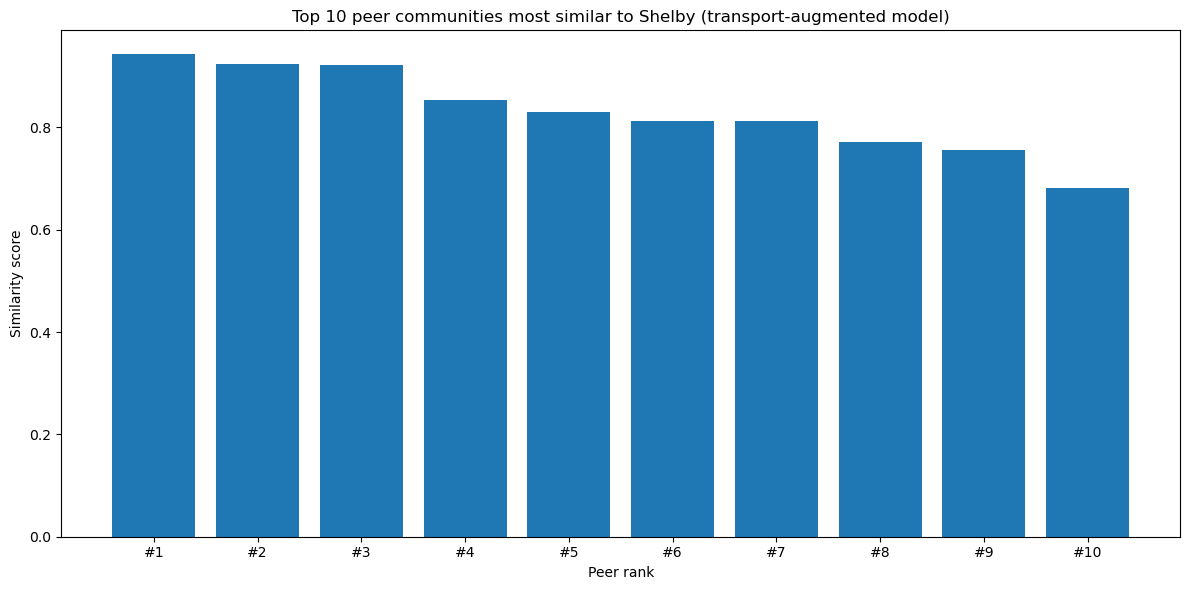

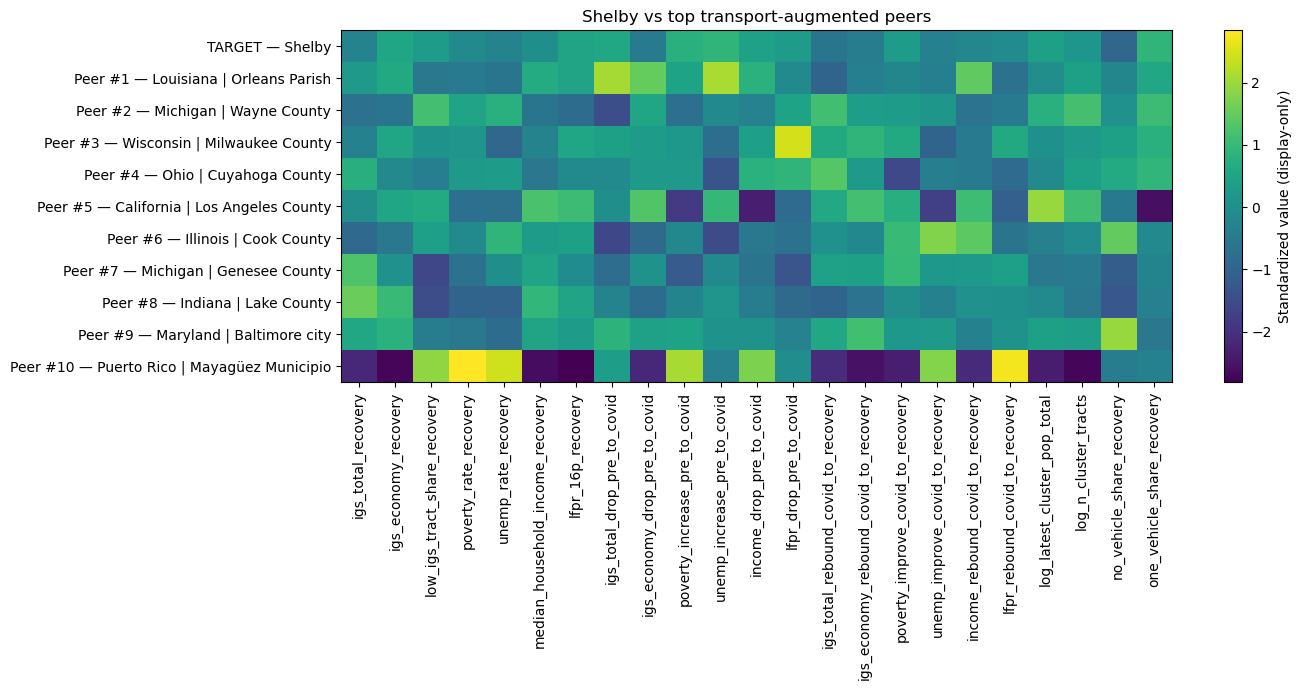

In [62]:
# Cell 10 — Quick visuals

# ------------------------------------------------------------
# A. Similarity score bar chart
# ------------------------------------------------------------
plot_df = peer_transport_top10.copy()

plt.figure(figsize=(12, 6))
plt.bar(
    x=[f"#{r}" for r in plot_df["peer_rank"]],
    height=plot_df["similarity_score"]
)
plt.title("Top 10 peer communities most similar to Shelby (transport-augmented model)")
plt.xlabel("Peer rank")
plt.ylabel("Similarity score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# B. Heatmap-style matrix using standardized values from the saved matrix
# ------------------------------------------------------------
heatmap_path = ML_DIR / f"{TRANSPORT_MODEL_NAME}_heatmap_matrix.csv"
heatmap_df = pd.read_csv(heatmap_path)

meta_path = ML_DIR / f"{TRANSPORT_MODEL_NAME}_meta.json"
with open(meta_path, "r") as f:
    meta = json.load(f)

heatmap_features = meta["features_used"]

heatmap_numeric = heatmap_df[heatmap_features].copy()
heatmap_numeric = heatmap_numeric.apply(pd.to_numeric, errors="coerce")

# Standardize within displayed rows only, just for easier plotting
heatmap_plot = heatmap_numeric.copy()
for c in heatmap_plot.columns:
    col = heatmap_plot[c]
    std = col.std(ddof=0)
    if pd.isna(std) or std == 0:
        heatmap_plot[c] = 0.0
    else:
        heatmap_plot[c] = (col - col.mean()) / std

plt.figure(figsize=(14, 7))
plt.imshow(heatmap_plot.values, aspect="auto")
plt.colorbar(label="Standardized value (display-only)")
plt.yticks(range(len(heatmap_df)), heatmap_df["display_label"].tolist())
plt.xticks(range(len(heatmap_features)), heatmap_features, rotation=90)
plt.title("Shelby vs top transport-augmented peers")
plt.tight_layout()
plt.show()

### Cell 11 — Shelby vs peers transport summary table

In [65]:
# Cell 11 — Shelby vs peers transport summary table (filled peer transport fields)

display_transport_cols = [
    "cluster_id",
    "display_state",
    "display_county",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "no_vehicle_share_recovery",
    "one_vehicle_share_recovery",
    "transit_stops_per_1000_2024",
    "transit_stops_per_sqmi_2024",
    "transport_vulnerability_score_cluster_ranked",
]

# Pull full transport/display info from peer_model_base for BOTH target and peers
display_lookup = peer_model_base[[c for c in display_transport_cols if c in peer_model_base.columns]].copy()

# Target row
target_row = display_lookup.loc[
    display_lookup["cluster_id"].astype(str) == str(TARGET_CLUSTER_ID)
].copy()

if target_row.empty:
    raise ValueError(f"Could not find target cluster in peer_model_base: {TARGET_CLUSTER_ID}")

target_row.insert(0, "peer_rank", 0)
target_row.insert(0, "label", "TARGET — Shelby")
target_row["similarity_score"] = 1.0

# Peer rows: merge peer ranking output with full transport/display lookup
peer_transport_summary = peer_transport_top10[
    ["peer_rank", "cluster_id", "similarity_score"]
].copy()

peer_transport_summary = peer_transport_summary.merge(
    display_lookup,
    on="cluster_id",
    how="left",
    validate="1:1"
)

peer_transport_summary["label"] = (
    "Peer #" + peer_transport_summary["peer_rank"].astype(str) + " — " +
    peer_transport_summary["display_state"].astype(str) + " | " +
    peer_transport_summary["display_county"].astype(str)
)

# Align columns
all_cols = sorted(set(target_row.columns).union(set(peer_transport_summary.columns)))
for c in all_cols:
    if c not in target_row.columns:
        target_row[c] = np.nan
    if c not in peer_transport_summary.columns:
        peer_transport_summary[c] = np.nan

shelby_peer_transport_table = pd.concat(
    [
        target_row[all_cols],
        peer_transport_summary[all_cols]
    ],
    ignore_index=True,
    sort=False
)

front_cols = [
    "label",
    "peer_rank",
    "cluster_id",
    "display_state",
    "display_county",
    "similarity_score",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "no_vehicle_share_recovery",
    "one_vehicle_share_recovery",
    "transit_stops_per_1000_2024",
    "transit_stops_per_sqmi_2024",
    "transport_vulnerability_score_cluster_ranked",
]
front_cols = [c for c in front_cols if c in shelby_peer_transport_table.columns]
other_cols = [c for c in shelby_peer_transport_table.columns if c not in front_cols]

shelby_peer_transport_table = shelby_peer_transport_table[front_cols + other_cols].copy()

shelby_peer_transport_table.to_csv(ML_DIR / "shelby_peer_transport_table.csv", index=False)

print(shelby_peer_transport_table)

                                          label  peer_rank                                     cluster_id display_state      display_county  similarity_score  n_cluster_tracts  \
0                               TARGET — Shelby          0         Tennessee | Shelby County | cluster_77     Tennessee       Shelby County          1.000000                96   
1          Peer #1 — Louisiana | Orleans Parish          1        Louisiana | Orleans Parish | cluster_33     Louisiana      Orleans Parish          0.942714               107   
2             Peer #2 — Michigan | Wayne County          2           Michigan | Wayne County | cluster_38      Michigan        Wayne County          0.924209               152   
3        Peer #3 — Wisconsin | Milwaukee County          3      Wisconsin | Milwaukee County | cluster_86     Wisconsin    Milwaukee County          0.922566                98   
4              Peer #4 — Ohio | Cuyahoga County          4            Ohio | Cuyahoga County | cluster_63